In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

In [3]:
# CustomerID 제거, 성별 인코딩
df=pd.read_csv('./data/Mall_Customers.csv')
df['Gender'] = (df['Gender'] == 'Male').astype(int)
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender']].values


In [4]:
X

array([[ 19,  15,  39,   1],
       [ 21,  15,  81,   1],
       [ 20,  16,   6,   0],
       [ 23,  16,  77,   0],
       [ 31,  17,  40,   0],
       [ 22,  17,  76,   0],
       [ 35,  18,   6,   0],
       [ 23,  18,  94,   0],
       [ 64,  19,   3,   1],
       [ 30,  19,  72,   0],
       [ 67,  19,  14,   1],
       [ 35,  19,  99,   0],
       [ 58,  20,  15,   0],
       [ 24,  20,  77,   0],
       [ 37,  20,  13,   1],
       [ 22,  20,  79,   1],
       [ 35,  21,  35,   0],
       [ 20,  21,  66,   1],
       [ 52,  23,  29,   1],
       [ 35,  23,  98,   0],
       [ 35,  24,  35,   1],
       [ 25,  24,  73,   1],
       [ 46,  25,   5,   0],
       [ 31,  25,  73,   1],
       [ 54,  28,  14,   0],
       [ 29,  28,  82,   1],
       [ 45,  28,  32,   0],
       [ 35,  28,  61,   1],
       [ 40,  29,  31,   0],
       [ 23,  29,  87,   0],
       [ 60,  30,   4,   1],
       [ 21,  30,  73,   0],
       [ 53,  33,   4,   1],
       [ 18,  33,  92,   1],
       [ 49,  

In [5]:
# StandardScaler로 x 스케일링
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

In [6]:
# PCA : 2개의 주성분으로 압축
# 4. PCA : 2개의 주성분으로 압축
pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_scaled)

# PCA 결과를 데이터프레임으로 변환
df_pca = pd.DataFrame(data=pca_data, columns=['PC1', 'PC2'])


In [7]:
# KMEANS 클러스터링 

# 5. K-Means 클러스터링 (k=5 가정)
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=0)
df_pca['Cluster'] = kmeans.fit_transform(pca_data).argmax(axis=1) # 혹은 kmeans.labels_

c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


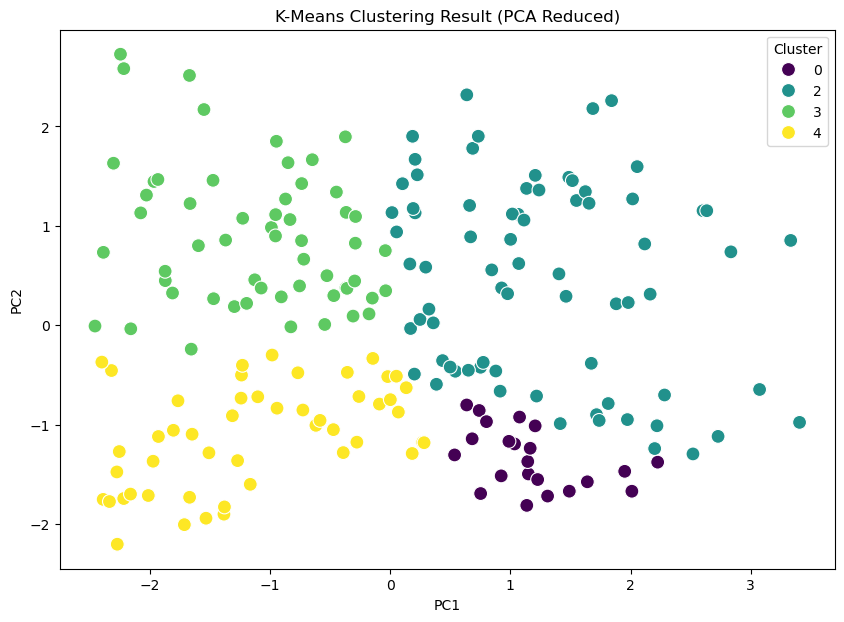

In [8]:
# KMeans 클러스터링 결과 시각화
# 6. KMeans 클러스터링 결과 시각화
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_pca, palette='viridis', s=100)
plt.title('K-Means Clustering Result (PCA Reduced)')
plt.show()

--- 군집별 특징(평균값) ---
         CustomerID    Gender        Age  Annual Income (k$)  \
Cluster                                                        
0         60.800000  0.490909  54.654545           44.181818   
1        104.212766  0.382979  31.446809           61.851064   
2         26.156250  0.312500  26.156250           27.593750   
3        169.870968  0.419355  31.935484           90.451613   
4        164.428571  0.571429  41.685714           88.228571   

         Spending Score (1-100)  
Cluster                          
0                     38.800000  
1                     54.553191  
2                     67.593750  
3                     83.032258  
4                     17.285714  


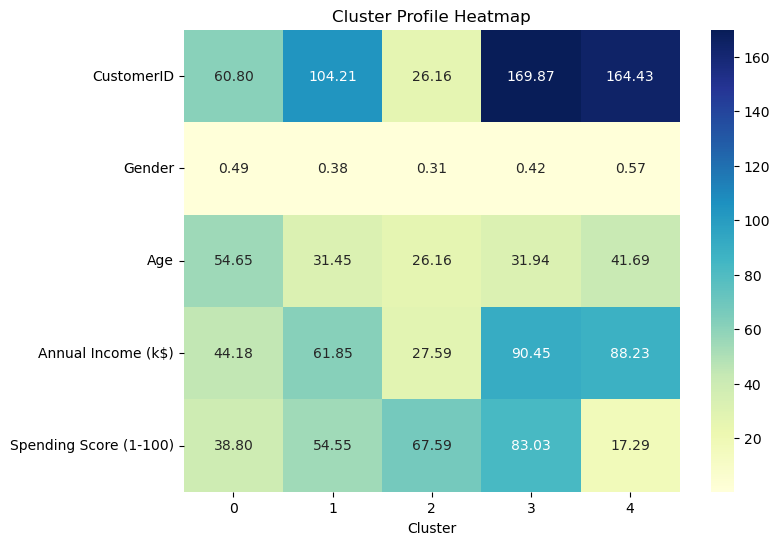

In [9]:
# 원본 데이터(df)에 군집 결과 추가
df['Cluster'] = kmeans.labels_

# 군집별 평균 데이터 계산 (성별은 비중으로 해석 가능)
cluster_analysis = df.groupby('Cluster').mean()

print("--- 군집별 특징(평균값) ---")
print(cluster_analysis)

# 시각적으로 확인하기 위한 히트맵 (선택 사항)
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(cluster_analysis.T, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Cluster Profile Heatmap')
plt.show()

c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarn

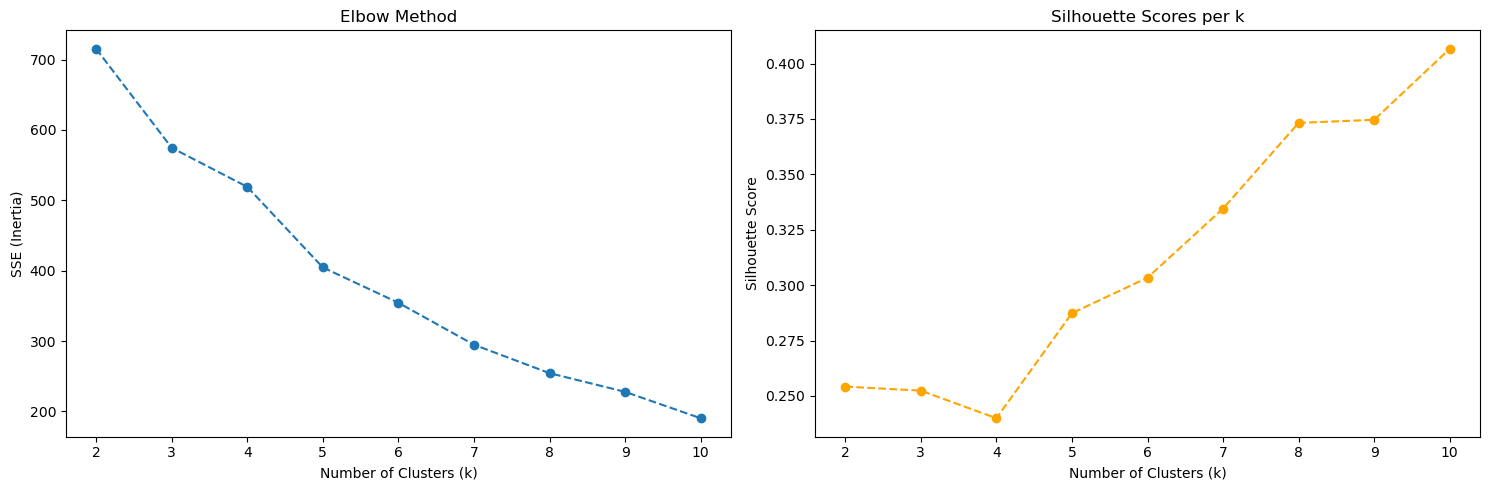

In [10]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# SSE와 실루엣 점수를 저장할 리스트
sse = []
silhouette_coefficients = []

# k를 2부터 10까지 변화시키며 측정
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(df_scaled)
    
    # 1. 엘보우 방법을 위한 SSE(Inertia) 저장
    sse.append(kmeans.inertia_)
    
    # 2. 실루엣 점수 계산 및 저장
    score = silhouette_score(df_scaled, kmeans.labels_)
    silhouette_coefficients.append(score)

# 시각화
plt.figure(figsize=(15, 5))

# 엘보우 방법 그래프
plt.subplot(1, 2, 1)
plt.plot(K_range, sse, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('SSE (Inertia)')
plt.title('Elbow Method')

# 실루엣 점수 그래프
plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_coefficients, marker='o', linestyle='--', color='orange')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores per k')

plt.tight_layout()
plt.show()

For n_clusters = 5, The average silhouette_score is : 0.4038


c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


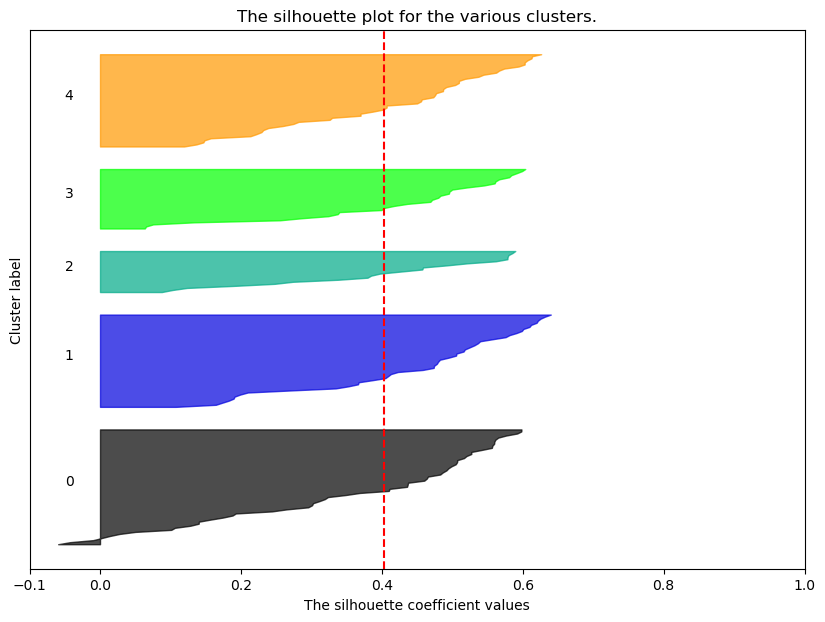

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

# 1. 데이터 로드 및 전처리 (이전 단계와 동일)
df = pd.read_csv('./data/Mall_Customers.csv')
df.drop('CustomerID', axis=1, inplace=True)
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

# 2. PCA 및 KMeans (k=5 가정)
pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_scaled)

n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42)
cluster_labels = kmeans.fit_predict(pca_data)

# 3. 실루엣 플롯 생성
fig, ax1 = plt.subplots(1, 1, figsize=(10, 7))

# 전체 실루엣 점수 계산
silhouette_avg = silhouette_score(pca_data, cluster_labels)
print(f"For n_clusters = {n_clusters}, The average silhouette_score is : {silhouette_avg:.4f}")

# 각 샘플별 실루엣 점수 계산
sample_silhouette_values = silhouette_samples(pca_data, cluster_labels)

y_lower = 10
for i in range(n_clusters):
    # i번째 클러스터에 해당하는 샘플들의 실루엣 점수를 추출하여 정렬
    ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.nipy_spectral(float(i) / n_clusters)
    ax1.fill_betweenx(np.arange(y_lower, y_upper),
                      0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)

    # 클러스터 번호 표시
    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

    # 다음 클러스터를 위한 y 위치 업데이트
    y_lower = y_upper + 10

ax1.set_title("The silhouette plot for the various clusters.")
ax1.set_xlabel("The silhouette coefficient values")
ax1.set_ylabel("Cluster label")

# 전체 평균 점수에 빨간 점선 표시
ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

ax1.set_yticks([])  # y축 눈금 제거
ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
plt.show()

# 초 개선버전

=== PCA 주성분별 설명 분산 비율 ===
주성분 (PC)  개별 설명 분산 비율  누적 설명 분산 비율
     PC1     0.336900     0.336900
     PC2     0.262306     0.599207
     PC3     0.232606     0.831813
     PC4     0.168187     1.000000




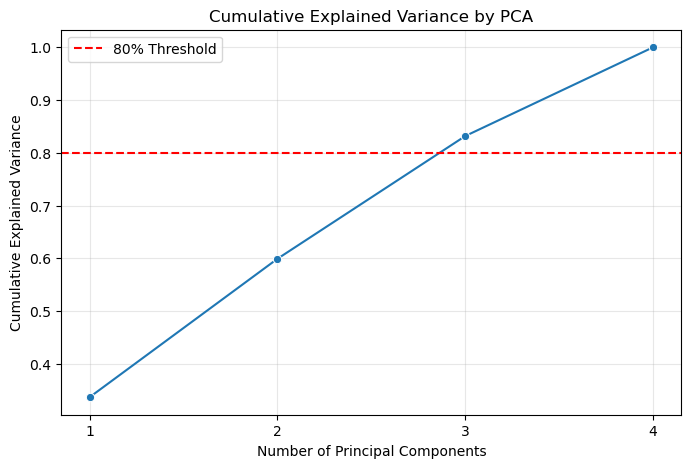

★ 원본 데이터의 80% 이상을 보존하기 위한 최적의 주성분 개수: 3개


In [16]:
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 기존 스케일링된 데이터(df_scaled 또는 X_scaled)로 전체 주성분에 대해 PCA 피팅
# (n_components를 지정하지 않으면 피처 개수만큼 주성분이 생성됩니다)
pca_test = PCA()
pca_test.fit(df_scaled)

# 2. 각 주성분이 설명하는 분산 비율 및 누적 분산 비율 계산
explained_variance_ratio = pca_test.explained_variance_ratio_
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

# 3. 수치형 데이터 표로 확인
pca_results_df = pd.DataFrame({
    '주성분 (PC)': [f'PC{i+1}' for i in range(len(explained_variance_ratio))],
    '개별 설명 분산 비율': explained_variance_ratio,
    '누적 설명 분산 비율': cumulative_variance_ratio
})

print("=== PCA 주성분별 설명 분산 비율 ===")
print(pca_results_df.to_string(index=False))
print("\n")

# 4. 누적 분산 비율 시각화 (Scree Plot)
plt.figure(figsize=(8, 5))
sns.lineplot(x=range(1, len(cumulative_variance_ratio) + 1), y=cumulative_variance_ratio, marker='o')

# 정보 보존율 80% 기준선 추가 (필요에 따라 0.9 등으로 수정 가능)
threshold = 0.8 
plt.axhline(y=threshold, color='red', linestyle='--', label=f'{int(threshold*100)}% Threshold')

plt.title('Cumulative Explained Variance by PCA')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.xticks(range(1, len(cumulative_variance_ratio) + 1))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5. 최적의 차원 선택 및 데이터 변환
# 누적 분산이 threshold(80%) 이상이 되는 최초의 차원 수 계산
optimal_n_components = np.argmax(cumulative_variance_ratio >= threshold) + 1
print(f"★ 원본 데이터의 {int(threshold*100)}% 이상을 보존하기 위한 최적의 주성분 개수: {optimal_n_components}개")

# 최적화된 개수로 최종 PCA 적용
pca_optimal = PCA(n_components=optimal_n_components)
df_pca_optimal = pca_optimal.fit_transform(df_scaled)

# 이후 이 df_pca_optimal 데이터를 KMeans 학습에 사용하시면 됩니다!

★ 원본 데이터의 80% 이상을 보존하기 위한 최적의 주성분 개수: 3개

=== 최적화된 PCA 적용 후 K값에 따른 군집화 평가 지표 ===
 K (군집 수)  WCSS (오차제곱합)  Silhouette Score (실루엣 점수)
        8    119.879074                   0.418561
        7    143.736500                   0.418225
        9    105.826461                   0.404737
       10     97.128957                   0.392251
        4    272.786035                   0.367560
        6    184.112772                   0.358110
        5    236.675324                   0.329819
        3    342.949268                   0.327362
        2    454.265074                   0.301486




c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarn

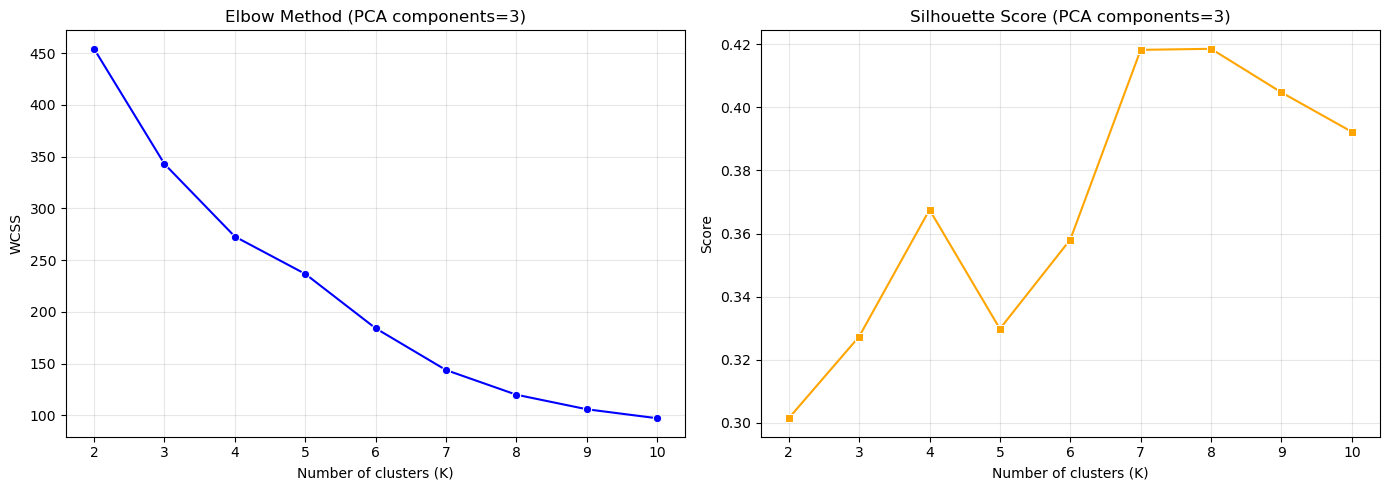

In [18]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# [1단계] PCA 최적 차원 찾기 및 변환
# ---------------------------------------------------------
# 임시로 전체 주성분에 대해 PCA를 수행하여 누적 분산 비율 확인
pca_full = PCA()
pca_full.fit(df_scaled)  # 변수명이 다르면 여기서 수정 (예: df_scaled)

cumulative_variance_ratio = np.cumsum(pca_full.explained_variance_ratio_)
threshold = 0.8  # 원본 데이터의 80% 분산 보존 기준

# 80% 이상을 보존하는 최초의 차원 수 계산
optimal_n_components = np.argmax(cumulative_variance_ratio >= threshold) + 1
print(f"★ 원본 데이터의 {int(threshold*100)}% 이상을 보존하기 위한 최적의 주성분 개수: {optimal_n_components}개\n")

# 최적화된 개수로 PCA 최종 적용
pca_optimal = PCA(n_components=optimal_n_components)
X_pca_optimal = pca_optimal.fit_transform(df_scaled)


# ---------------------------------------------------------
# [2단계] 변환된 데이터로 최적의 K값 찾기 (Elbow & Silhouette)
# ---------------------------------------------------------
wcss = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_pca_optimal)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_pca_optimal, kmeans.labels_))


# ---------------------------------------------------------
# [3단계] 수치형 데이터 표 출력
# ---------------------------------------------------------
results_df = pd.DataFrame({
    'K (군집 수)': list(k_range),
    'WCSS (오차제곱합)': wcss,
    'Silhouette Score (실루엣 점수)': silhouette_scores
})

print("=== 최적화된 PCA 적용 후 K값에 따른 군집화 평가 지표 ===")
# 실루엣 점수가 가장 높은 순(내림차순)으로 정렬하여 출력
print(results_df.sort_values(by='Silhouette Score (실루엣 점수)', ascending=False).to_string(index=False))
print("\n")


# ---------------------------------------------------------
# [4단계] 시각화 도표 출력
# ---------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Method 그래프
sns.lineplot(x=list(k_range), y=wcss, marker='o', ax=ax[0], color='blue')
ax[0].set_title(f'Elbow Method (PCA components={optimal_n_components})')
ax[0].set_xlabel('Number of clusters (K)')
ax[0].set_ylabel('WCSS')
ax[0].grid(True, alpha=0.3)

# Silhouette Score 그래프
sns.lineplot(x=list(k_range), y=silhouette_scores, marker='s', ax=ax[1], color='orange')
ax[1].set_title(f'Silhouette Score (PCA components={optimal_n_components})')
ax[1].set_xlabel('Number of clusters (K)')
ax[1].set_ylabel('Score')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. 데이터 로드 및 전처리
# (경로는 기존 노트북에 맞춰 './data/Mall_Customers.csv'로 설정했습니다)
df = pd.read_csv('./data/Mall_Customers.csv')

# 모델 학습용 데이터프레임 복사 및 전처리
df_processed = df.copy()
df_processed['Gender'] = (df_processed['Gender'] == 'Male').astype(int)
X = df_processed[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender']]

# 2. 데이터 스케일링 (StandardScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. PCA 최적 차원 축소 (원본 데이터 정보 80% 보존 기준)
pca_full = PCA()
pca_full.fit(X_scaled)
cumulative_variance_ratio = np.cumsum(pca_full.explained_variance_ratio_)
optimal_n_components = np.argmax(cumulative_variance_ratio >= 0.8) + 1

pca_optimal = PCA(n_components=optimal_n_components)
X_pca_optimal = pca_optimal.fit_transform(X_scaled)
print(f"▶ PCA 적용: 총 {optimal_n_components}개의 주성분으로 축소되었습니다.\n")

# 4. 실루엣 점수 기반 '최적의 K' 자동 탐색 (K=2~10)
best_k = 2
best_score = -1

for k in range(2, 11):
    kmeans_temp = KMeans(n_clusters=k, init='k-means++', random_state=42)
    labels_temp = kmeans_temp.fit_predict(X_pca_optimal)
    score = silhouette_score(X_pca_optimal, labels_temp)
    
    if score > best_score:
        best_score = score
        best_k = k

print(f"▶ 자동 탐색된 최적의 군집 수(K): {best_k} (최고 실루엣 점수: {best_score:.4f})\n")

# 5. 최적의 K로 최종 K-Means 군집화 수행
kmeans_final = KMeans(n_clusters=best_k, init='k-means++', random_state=42)
# 원본 데이터프레임에 'Cluster'라는 새로운 컬럼으로 세그먼트 결과 추가
df['Cluster'] = kmeans_final.fit_predict(X_pca_optimal)

# 6. 각 고객 세그먼트(군집)별 프로필(평균값) 요약 및 분석
# 나이, 연봉, 지출 점수의 평균 계산
segment_profile = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()

# 성별(남성 비율) 및 해당 군집의 고객 수 계산 추가
segment_profile['Male_Ratio(%)'] = df.groupby('Cluster')['Gender'].apply(lambda x: (x == 'Male').mean() * 100)
segment_profile['Customer_Count'] = df.groupby('Cluster')['CustomerID'].count()

print("=== 📊 최종 고객 세그먼트별 프로필 (평균 요약) ===")
print(segment_profile.round(2)) # 소수점 둘째 자리까지 출력

# 7. 군집화 결과가 포함된 최종 데이터를 새로운 CSV 파일로 저장
save_path = './data/Mall_Customers_Segmented.csv'
df.to_csv(save_path, index=False)
print(f"\n▶ 세그먼트 라벨이 추가된 최종 데이터가 '{save_path}'에 성공적으로 저장되었습니다.")

▶ PCA 적용: 총 3개의 주성분으로 축소되었습니다.

▶ 자동 탐색된 최적의 군집 수(K): 8 (최고 실루엣 점수: 0.4186)

=== 📊 최종 고객 세그먼트별 프로필 (평균 요약) ===
           Age  Annual Income (k$)  Spending Score (1-100)  Male_Ratio(%)  \
Cluster                                                                     
0        56.54               46.18                   40.04          100.0   
1        29.62               77.82                   68.18            0.0   
2        44.60               92.33                   21.60            0.0   
3        23.79               30.79                   69.36          100.0   
4        26.70               32.83                   66.96            0.0   
5        30.65               78.81                   72.92          100.0   
6        49.42               46.25                   39.72            0.0   
7        39.50               85.15                   14.05          100.0   

         Customer_Count  
Cluster                  
0                    28  
1                    34  
2             

c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarn